<a href="https://colab.research.google.com/github/dntwaritag/ASP2024/blob/main/dntwarit_MBD_signment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Names: Denys Ntwaritaganzwa

Andrew id: dntwarit

Course: Mobile Big Data Analytics & Management

# Imports & Environment Setup

In [1]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# File path handling
from pathlib import Path

from google.colab import userdata
import os

# Store your credentials in Colab Secrets first (see below)
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!kaggle datasets download -d marcodena/mobile-phone-activity #marcodena/mobile-phone-activity
!unzip mobile-phone-activity.zip

# Visualization settings for clean academic plots
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


Dataset URL: https://www.kaggle.com/datasets/marcodena/mobile-phone-activity
License(s): DbCL-1.0
 56% 135M/242M [00:00<00:00, 1.41GB/s]
100% 242M/242M [00:00<00:00, 703MB/s] 
Archive:  mobile-phone-activity.zip
  inflating: ISTAT_census_variables_2011.csv  
  inflating: Italian_provinces.geojson  
  inflating: mi-to-provinces-2013-11-01.csv  
  inflating: mi-to-provinces-2013-11-02.csv  
  inflating: mi-to-provinces-2013-11-03.csv  
  inflating: mi-to-provinces-2013-11-04.csv  
  inflating: mi-to-provinces-2013-11-05.csv  
  inflating: mi-to-provinces-2013-11-06.csv  
  inflating: mi-to-provinces-2013-11-07.csv  
  inflating: milano-grid.geojson     
  inflating: sms-call-internet-mi-2013-11-01.csv  
  inflating: sms-call-internet-mi-2013-11-02.csv  
  inflating: sms-call-internet-mi-2013-11-03.csv  
  inflating: sms-call-internet-mi-2013-11-04.csv  
  inflating: sms-call-internet-mi-2013-11-05.csv  
  inflating: sms-call-internet-mi-2013-11-06.csv  
  inflating: sms-call-internet-mi-

# Dataset Paths and File Names

In [2]:
# Path to the data directory
data_path = Path("../content")

# List of dataset files to load
files = [
    "sms-call-internet-mi-2013-11-02.csv",
    "sms-call-internet-mi-2013-11-04.csv",
    "sms-call-internet-mi-2013-11-06.csv"
]


# Load, Parse Time, and Merge Data (TASK 1)

In [3]:
# List to store individual DataFrames
dfs = []

for file in files:
    # Load CSV
    df = pd.read_csv(data_path / file)

    # Convert Unix timestamp (milliseconds) to datetime
    df["timestamp"] = pd.to_datetime(df["datetime"])

    # Extract date and hour for temporal analysis
    df["date"] = df["timestamp"].dt.date
    df["hour"] = df["timestamp"].dt.hour

    dfs.append(df)

# Combine all datasets into one DataFrame
data = pd.concat(dfs, ignore_index=True)

# Preview merged dataset
data.head()

,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet,timestamp,date,hour
0,2013-11-02 00:00:00,1,0,0.2445,NaN,NaN,NaN,NaN,2013-11-02,2013-11-02,0
1,2013-11-02 00:00:00,1,39,1.4952,1.1213,0.2708,0.3004,46.5094,2013-11-02,2013-11-02,0
2,2013-11-02 00:00:00,1,53,0.0018,0.0036,NaN,NaN,NaN,2013-11-02,2013-11-02,0
3,2013-11-02 00:00:00,2,0,0.2458,NaN,NaN,NaN,NaN,2013-11-02,2013-11-02,0
4,2013-11-02 00:00:00,2,39,1.5028,1.1243,0.2751,0.3023,46.6933,2013-11-02,2013-11-02,0


# Data Overview (Required Questions)

In [4]:
# Total number of records
total_records = len(data)

# Number of unique grid squares
unique_cells = data["CellID"].nunique()

# Number of unique country codes
unique_country_codes = data["countrycode"].nunique()

print("Total records:", total_records)
print("Unique CellIDs:", unique_cells)
print("Unique country codes:", unique_country_codes)

Total records: 6564031
Unique CellIDs: 10000
Unique country codes: 302


# Missing Values Detection

In [5]:
# Count missing values per column
missing_before = data.isna().sum()

missing_before


,0
datetime,0
CellID,0
countrycode,0
smsin,3964171
smsout,5025738
callin,4761685
callout,3764484
internet,3621117
timestamp,0
date,0


# Columns with Most Missing Values

In [6]:
# Sort columns by missing value count
missing_before.sort_values(ascending=False)


,0
smsout,5025738
callin,4761685
smsin,3964171
callout,3764484
internet,3621117
datetime,0
CellID,0
countrycode,0
timestamp,0
date,0


# Mean Imputation

In [7]:
# Select numeric columns only
numeric_cols = data.select_dtypes(include=np.number).columns

# Count number of NaN values before imputation
nan_mask = data[numeric_cols].isna()
records_modified = nan_mask.sum().sum()

# Fill missing numeric values with column means
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# Verify missing values after imputation
missing_after = data.isna().sum()

print("Missing values after imputation:")
missing_after
print("Total values modified:", records_modified)


Missing values after imputation:
Total values modified: 21137195


# Feature Engineering (Aggregate Columns)

In [8]:
# Aggregate SMS activity
data["total_sms"] = data["smsin"] + data["smsout"]

# Aggregate call activity
data["total_calls"] = data["callin"] + data["callout"]

# Internet activity (already aggregated)
data["total_internet"] = data["internet"]

data[["total_sms", "total_calls", "total_internet"]].head()


,total_sms,total_calls,total_internet
0,7.685251,13.425298,101.976153
1,2.616500,0.571200,46.509400
2,0.005400,13.425298,101.976153
3,7.686551,13.425298,101.976153
4,2.627100,0.577400,46.693300


# Hourly Aggregation (Temporal Analysis)

In [9]:
# Aggregate activity by hour
hourly_activity = data.groupby("hour")[["total_sms", "total_calls", "total_internet"]].sum()

# Total activity across all types
hourly_activity["total_activity"] = hourly_activity.sum(axis=1)

hourly_activity


,total_sms,total_calls,total_internet,total_activity
hour,,,,
0,1.793529e+06,1.544151e+06,1.686987e+07,2.020755e+07
1,1.256787e+06,1.185631e+06,1.318190e+07,1.562431e+07
2,1.044790e+06,1.028140e+06,1.110928e+07,1.318221e+07
3,9.772733e+05,9.711108e+05,9.912125e+06,1.186051e+07
4,1.127516e+06,1.100273e+06,9.549219e+06,1.177701e+07
5,1.315376e+06,1.248683e+06,1.067705e+07,1.324111e+07
6,1.986819e+06,1.791456e+06,1.435237e+07,1.813065e+07
7,3.232475e+06,2.762777e+06,2.162059e+07,2.761585e+07
8,5.061730e+06,4.222455e+06,2.977722e+07,3.906140e+07


# Peak and Lowest Activity Hours

In [10]:
# Identify peak and lowest activity hours
peak_hour = hourly_activity["total_activity"].idxmax()
lowest_hour = hourly_activity["total_activity"].idxmin()

print("Peak activity hour:", peak_hour)
print("Lowest activity hour:", lowest_hour)


Peak activity hour: 17
Lowest activity hour: 4


# Hourly Call Statistics (Mean, Median, Std, Min, Max)

In [11]:
call_statistics = hourly_activity["total_calls"].agg(
    ["mean", "median", "std", "min", "max"]
)

call_statistics


,total_calls
mean,3.671836e+06
median,4.145010e+06
std,1.876943e+06
min,9.711108e+05
max,5.801570e+06


# Plot Hourly Activity

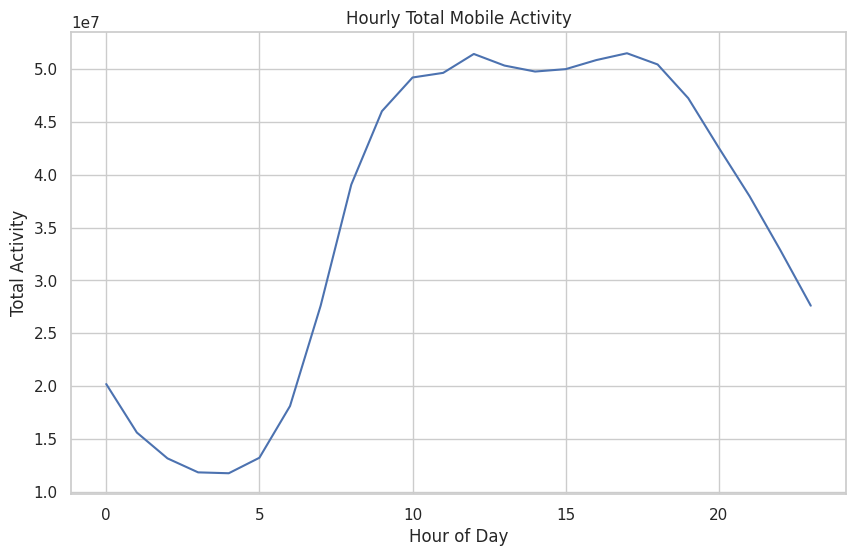

In [12]:
# Plot total activity by hour
hourly_activity["total_activity"].plot()
plt.title("Hourly Total Mobile Activity")
plt.xlabel("Hour of Day")
plt.ylabel("Total Activity")

# Create the directory if it doesn't exist
Path("../outputs/figures/").mkdir(parents=True, exist_ok=True)

plt.savefig("../outputs/figures/hourly_activity.png")
plt.show()

# Daytime vs Nighttime Definition

In [13]:
# Daytime: 06:00–20:00
daytime = data[(data["hour"] >= 6) & (data["hour"] < 20)]

# Nighttime: 20:00–06:00
nighttime = data[(data["hour"] < 6) | (data["hour"] >= 20)]


# Daytime vs Nighttime Percentages

In [14]:
day_pct = daytime[["total_sms", "total_calls", "total_internet"]].sum().sum() / data[["total_sms", "total_calls", "total_internet"]].sum().sum() * 100
night_pct = nighttime[["total_sms", "total_calls", "total_internet"]].sum().sum() / data[["total_sms", "total_calls", "total_internet"]].sum().sum() * 100

print("Daytime activity (%):", day_pct)
print("Nighttime activity (%):", night_pct)

Daytime activity (%): 73.55098728067262
Nighttime activity (%): 26.44901271932746


# Domestic vs International Classification

In [15]:
# Italy country code = 39
domestic = data[data["countrycode"] == 39]
international = data[data["countrycode"] != 39]


# Call Percentages (NumPy-based)

In [16]:
call_domestic_pct = np.sum(domestic["total_calls"]) / np.sum(data["total_calls"]) * 100
call_international_pct = np.sum(international["total_calls"]) / np.sum(data["total_calls"]) * 100

call_domestic_pct = float(call_domestic_pct)
call_international_pct = float(call_international_pct)
call_domestic_pct, call_international_pct


(33.10585798101129, 66.89414201898873)

# SMS Percentages (NumPy-based)

In [17]:
sms_domestic_pct = np.sum(domestic["total_sms"]) / np.sum(data["total_sms"]) * 100
sms_international_pct = np.sum(international["total_sms"]) / np.sum(data["total_sms"]) * 100

sms_domestic_pct = float(sms_domestic_pct)
sms_international_pct = float(sms_international_pct)
sms_domestic_pct, sms_international_pct


(24.98114534196831, 75.01885465803169)

# International Incoming vs Outgoing Call Ratio

In [18]:
international_in_out_ratio = (
    np.sum(international["callin"]) /
    np.sum(international["callout"])
)

international_in_out_ratio = float(international_in_out_ratio)
international_in_out_ratio


1.6749130036154924

# Hourly Pattern Comparison Plot

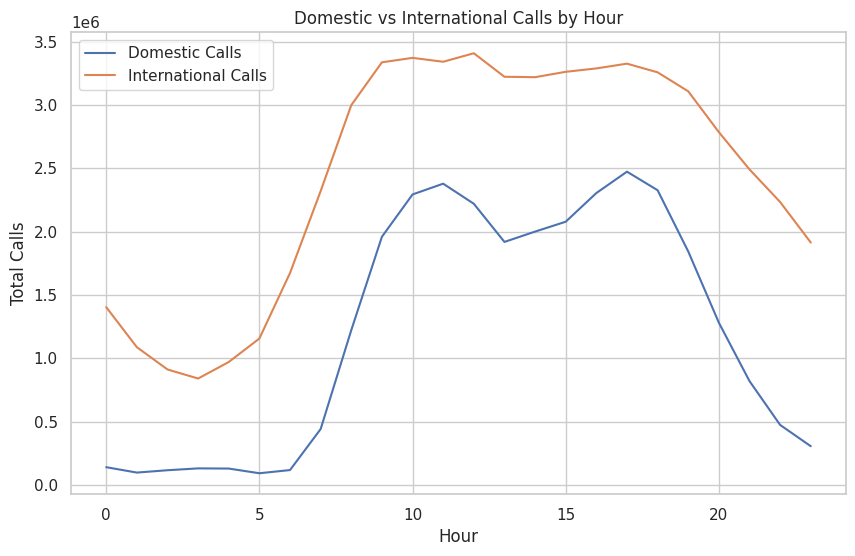

In [19]:
plt.plot(domestic.groupby("hour")["total_calls"].sum(), label="Domestic Calls")
plt.plot(international.groupby("hour")["total_calls"].sum(), label="International Calls")
plt.legend()
plt.title("Domestic vs International Calls by Hour")
plt.xlabel("Hour")
plt.ylabel("Total Calls")
plt.savefig("../outputs/figures/domestic_vs_international.png")
plt.show()


# Grid-Level Aggregation for Correlation

In [20]:
grid_level = data.groupby("CellID")[["total_sms", "total_calls"]].sum()
grid_level.head()

,total_sms,total_calls
CellID,,
1,3660.014242,3256.963483
2,3666.749942,3262.824583
3,3144.500052,2913.376076
4,3640.510942,3240.004983
5,3727.018236,3308.785358


# Correlation Using NumPy

In [21]:
correlation_sms_calls = np.corrcoef(
    grid_level["total_sms"],
    grid_level["total_calls"]
)[0, 1]

correlation_sms_calls


np.float64(0.9862350324230829)

# Correlation Visualization

Object `build` not found.


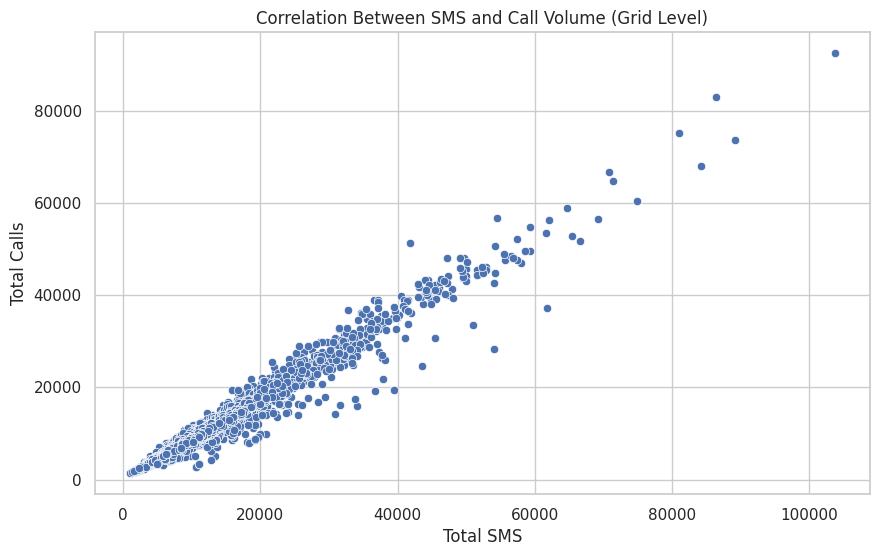

In [22]:
sns.scatterplot(
    x=grid_level["total_sms"],
    y=grid_level["total_calls"]
)
plt.title("Correlation Between SMS and Call Volume (Grid Level)")
plt.xlabel("Total SMS")
plt.ylabel("Total Calls")
What can I help you build?
0 / 2000

plt.savefig("../outputs/figures/correlation_sms_calls.png")
plt.show()


### Briefly

- Mobile activity peaks during daytime working hours.
- Nighttime activity is lower but consistent.
- Domestic traffic dominates both calls and SMS.
- International calls show different temporal patterns.
- SMS and call volumes are positively correlated at grid level.
